# Linear Regression from Scratch
In this notebook, we will explore the fundamentals of Linear Regression. We'll start by visualizing data, then manually tune parameters, and finally implement Gradient Descent to find the optimal fit.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default styles for our plots
sns.set_theme()

## 1. Data Preparation
We'll define a simple dataset representing years of experience and the corresponding salary.

In [52]:
X = np.array([1 , 3, 4, 6, 7]) # Input feature: years of experience
y = np.array([15,35,45,65,75]) # Target value: salary (in thousands)

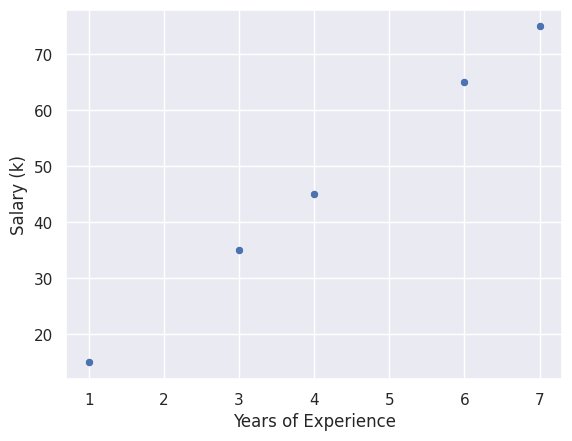

In [53]:
# Visualize the relationship between experience and salary
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()

## 2. Prediction Function
The linear model is defined as $f(x) = wx + b$. Here we create a function to generate predictions for our dataset.

In [54]:
def make_predictions(X,y,w,b):
  m=X.shape[0]
  pred_list=np.zeros(m)

  for i in range(m):
    pred_list[i]=w*X[i]+b

  return pred_list


Predictions: [0. 0. 0. 0. 0.]


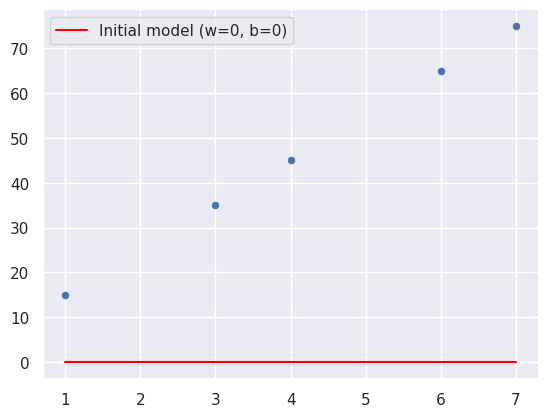

In [55]:
predictions=make_predictions(X,y,0,0)

print(f"Predictions: {predictions}")

# Visualize how this 'zero' model fits the data

sns.scatterplot(x=X, y=y)
plt.plot(X,predictions,color='red',label='Initial model (w=0, b=0)')
plt.legend()
plt.show()

Predictions: [1. 3. 4. 6. 7.]


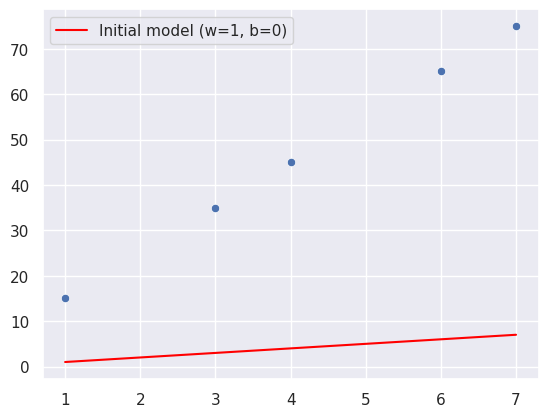

In [56]:
predictions=make_predictions(X,y,1,0)

print(f"Predictions: {predictions}")

# Visualize how this 'zero' model fits the data

sns.scatterplot(x=X, y=y)
plt.plot(X,predictions,color='red',label='Initial model (w=1, b=0)')
plt.legend()
plt.show()

Predictions: [15. 35. 45. 65. 75.]


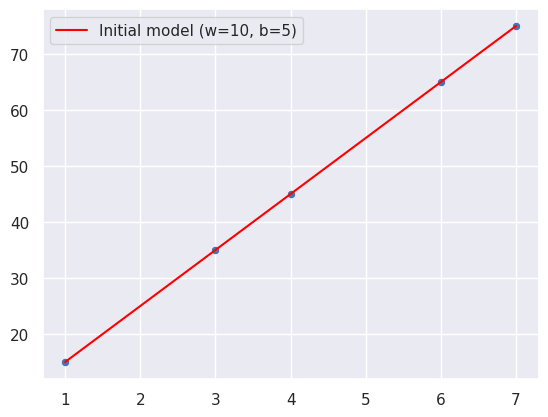

In [57]:
predictions=make_predictions(X,y,10,5)

print(f"Predictions: {predictions}")

# Visualize how this 'zero' model fits the data

sns.scatterplot(x=X, y=y)
plt.plot(X,predictions,color='red',label='Initial model (w=10, b=5)')
plt.legend()
plt.show()

## 3. Cost Function
To evaluate how well our model fits, we calculate the 'Cost' (Mean Squared Error). A lower cost means a better fit.

In [58]:
def compute_cost(X,y,w,b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy"""

  m=X.shape[0]
  cost=0.0

  for i in range(m):
    prediction=w*X[i]+b
    error=prediction-y[i]
    error_sqr=error ** 2
    cost=cost+error_sqr

  # We divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost


## 4. Visualizing the Cost
Let's see how the cost changes as we vary the weight $w$ while keeping $b$ constant. This produces a convex 'U-shaped' curve.

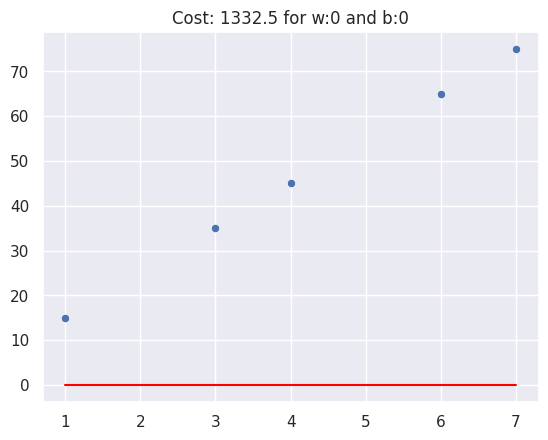

In [59]:
w=0
b=0
predictions=make_predictions(X,y,w,b)
total_cost=compute_cost(X,y,w,b)

sns.scatterplot(x=X,y=y)
plt.plot(X,predictions,color='red')
plt.title(f"Cost: {total_cost} for w:{w} and b:{b}")
plt.show()
plt.show()

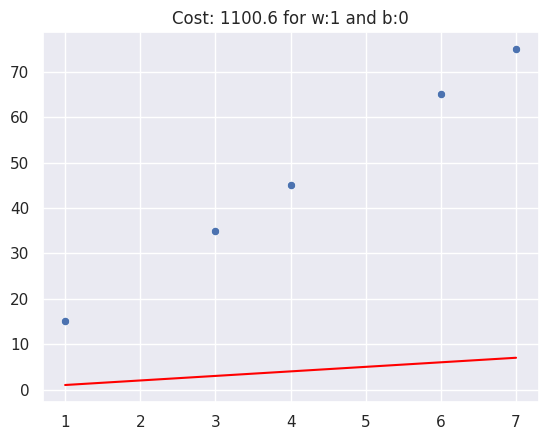

In [60]:
w=1
b=0
predictions=make_predictions(X,y,w,b)
total_cost=compute_cost(X,y,w,b)

sns.scatterplot(x=X,y=y)
plt.plot(X,predictions,color='red')
plt.title(f"Cost: {total_cost} for w:{w} and b:{b}")
plt.show()
plt.show()

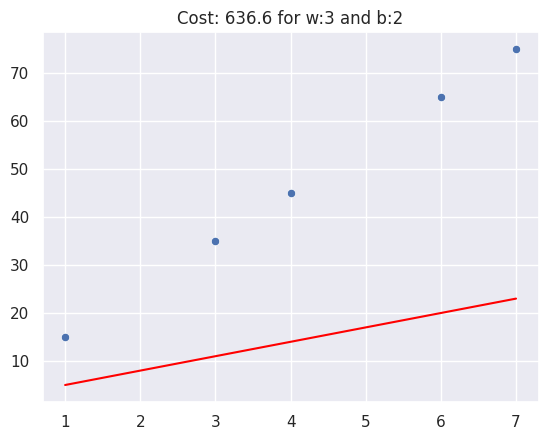

In [61]:
w=3
b=2
predictions=make_predictions(X,y,w,b)
total_cost=compute_cost(X,y,w,b)

sns.scatterplot(x=X,y=y)
plt.plot(X,predictions,color='red')
plt.title(f"Cost: {total_cost} for w:{w} and b:{b}")
plt.show()
plt.show()

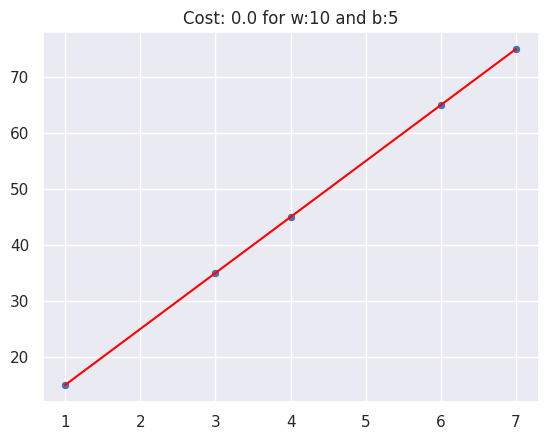

In [62]:
w=10
b=5
predictions=make_predictions(X,y,w,b)
total_cost=compute_cost(X,y,w,b)

sns.scatterplot(x=X,y=y)
plt.plot(X,predictions,color='red')
plt.title(f"Cost: {total_cost} for w:{w} and b:{b}")
plt.show()
plt.show()

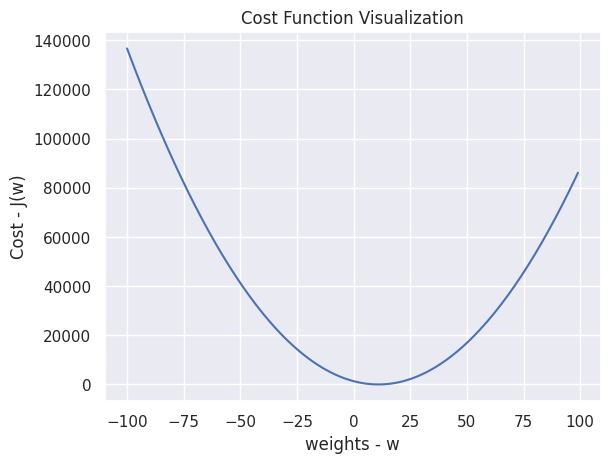

In [63]:
w_range = []
cost_history = []

# Loop through different weight values to see how they affect the cost
for i in range(-100,100):
  cost_i=compute_cost(X,y,w=i,b=0)
  w_range.append(i)
  cost_history.append(cost_i)

# Plotting the Cost Function: The goal of ML is to find the bottom of this 'U'
plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

## 5. Gradient Descent
Instead of guessing, we use the gradient (slope) to update $w$ and $b$ automatically until the cost is minimized.

In [64]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b"""
  m = X.shape[0]
  dj_dw = 0.0 # Change needed for weight
  dj_db = 0.0 # Change needed for bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [65]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost=compute_cost(X,y,w,b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Run Gradient Descent
We initialize $w$ and $b$ at 0 and let the algorithm find the best values.

In [71]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

## 6. Final Results & Prediction
Now we can use our optimized parameters to predict the salary for someone with 2 years of experience.

Optimized w: 10.4668, b: 2.5544


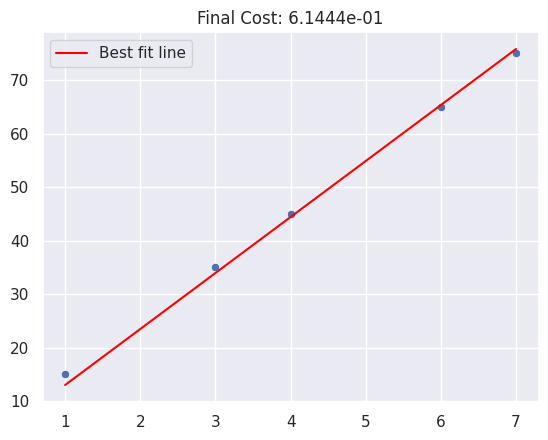

In [67]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_predictions(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [68]:
# Example: Predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 23.49k


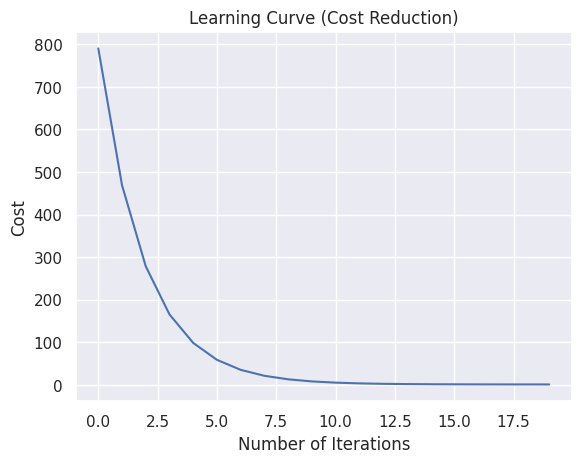

In [69]:
# Plot the cost over the first 20 iterations to see it dropping
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()